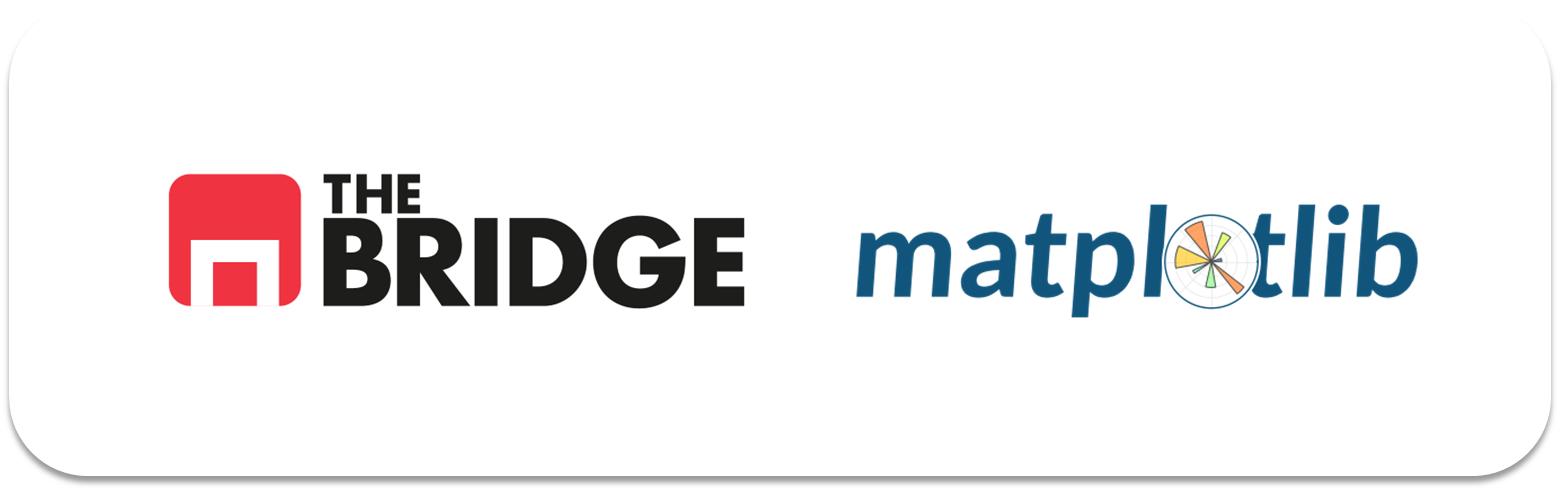

## PRACTICA OBLIGATORIA: **Visualización Básica**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de construcción de gráficas. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import matplotlib as mlp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### Ejercicio 1

#### #1.1

- Carga el dataset de casas de California que está en la ruta "./data/california_cities.csv".  
- Muestra parte de su contenido y su descripción.  
- Deshazte de las filas con nulos.

In [2]:
df_cities = pd.read_csv("./data/california_cities.csv")

In [3]:
df_cities.head(20)

,Unnamed: 0,city,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent
0,0,Adelanto,34.576111,-117.432778,875.0,2871.0,31765,56.027,56.009,0.018,145.107,145.062,0.046,0.03
1,1,AgouraHills,34.153333,-118.761667,281.0,922.0,20330,7.822,7.793,0.029,20.260,20.184,0.076,0.37
2,2,Alameda,37.756111,-122.274444,NaN,33.0,75467,22.960,10.611,12.349,59.465,27.482,31.983,53.79
3,3,Albany,37.886944,-122.297778,NaN,43.0,18969,5.465,1.788,3.677,14.155,4.632,9.524,67.28
4,4,Alhambra,34.081944,-118.135000,150.0,492.0,83089,7.632,7.631,0.001,19.766,19.763,0.003,0.01
5,5,AlisoViejo,33.575000,-117.725556,127.0,417.0,47823,7.472,7.472,0.000,19.352,19.352,0.000,0.00
6,6,Alturas,41.487222,-120.542500,1332.0,4370.0,2827,2.449,2.435,0.014,6.342,6.306,0.036,0.57
7,7,AmadorCity,38.419444,-120.824167,280.0,919.0,185,0.314,0.314,0.000,0.813,0.813,0.000,0.00
8,8,AmericanCanyon,38.168056,-122.252500,14.0,46.0,19454,4.845,4.837,0.008,12.548,12.527,0.021,0.17
9,9,Anaheim,33.836111,-117.889722,48.0,157.0,336000,50.811,49.835,0.976,131.600,129.073,2.527,1.92


In [4]:
df_cities.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 482 entries, 0 to 481
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          482 non-null    int64  
 1   city                482 non-null    object 
 2   latd                482 non-null    float64
 3   longd               482 non-null    float64
 4   elevation_m         434 non-null    float64
 5   elevation_ft        470 non-null    float64
 6   population_total    482 non-null    int64  
 7   area_total_sq_mi    480 non-null    float64
 8   area_land_sq_mi     482 non-null    float64
 9   area_water_sq_mi    481 non-null    float64
 10  area_total_km2      477 non-null    float64
 11  area_land_km2       478 non-null    float64
 12  area_water_km2      478 non-null    float64
 13  area_water_percent  477 non-null    float64
dtypes: float64(11), int64(2), object(1)
memory usage: 52.8+ KB


In [5]:
# Elimino las filas con nulos
df_cities.dropna(inplace=True)

In [6]:
df_cities.info()

<class 'pandas.core.frame.DataFrame'>
Index: 427 entries, 0 to 481
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          427 non-null    int64  
 1   city                427 non-null    object 
 2   latd                427 non-null    float64
 3   longd               427 non-null    float64
 4   elevation_m         427 non-null    float64
 5   elevation_ft        427 non-null    float64
 6   population_total    427 non-null    int64  
 7   area_total_sq_mi    427 non-null    float64
 8   area_land_sq_mi     427 non-null    float64
 9   area_water_sq_mi    427 non-null    float64
 10  area_total_km2      427 non-null    float64
 11  area_land_km2       427 non-null    float64
 12  area_water_km2      427 non-null    float64
 13  area_water_percent  427 non-null    float64
dtypes: float64(11), int64(2), object(1)
memory usage: 50.0+ KB


#### #1.2  

Recrea la siguiente figura, para ello construye en apartados separados cada gráfico y luego haz un apartado en el que se junten los cuatro.  

Las figuras son:
1. Las ciudades más pobladas, con los numeros de las poblaciones (tendrás que usar texto y recordar que para centrarlos se necesita poner el argumento `ha` a "center"). (Colores: azul, gris, aceituna, marrón, con trasparencia)  

2. Histograma del área total ocupada por las ciudades. (50 bins, fuente = "Bradley Hand ITC", tamaño 18, color azul acero o "steelblue")
3. El scatter de área de agua de un ciudad con su poblacion.
4. El boxplot de la altura de las ciudades.

In [7]:
# 1. las 5 ciudades más pobladas
def graph1(ax):
    top5 = df_cities["population_total"].nlargest(5)
    x = df_cities.loc[top5.index, "city"]
    y = top5.values.astype(float) / 1000
    
    ax.bar(x, y, color=["blue", "gray", "hotpink", "olive", "brown"], alpha=0.3)

    font8 = {'size': 8}

    ax.set_xlabel("Ciudades", fontdict=font8)
    ax.set_ylabel("Habitantes (miles)", fontdict=font8)
    ax.set_title("Ciudades más pobladas de California", fontdict=font8)
    ax.set_ylim([0, 5000])

    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

    for i, v in enumerate(y):
        ax.text(i, v + 300, f"{v}", ha="center", va="top", fontsize=8)
 

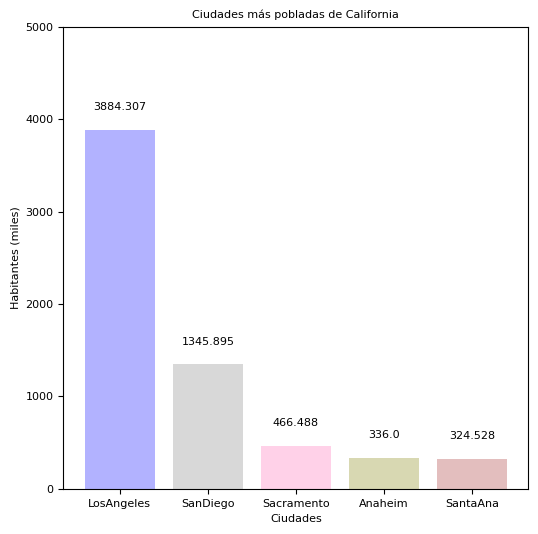

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))
graph1(ax)

In [9]:
# 2. Histograma del área total ocupada por las ciudades. 
# (50 bins, fuente = "Bradley Hand ITC", tamaño 18, color azul acero o "steelblue")
from matplotlib.patches import Patch

def graph2(ax):

    font = {'family': 'Bradley Hand ITC', 'size': 18}
    ax.set_xlabel("Superfície (km$^2$)", fontdict=font)
    ax.set_ylabel("Número de ciudades", fontdict=font)

    area = df_cities["area_total_km2"]

    ax.hist(area, bins = 50, alpha = 0.6, color = "steelblue")

    legend_patch = Patch(color="skyblue", label="Hist Area")
    ax.legend(handles=[legend_patch], loc="upper right", frameon=True, fontsize=8);

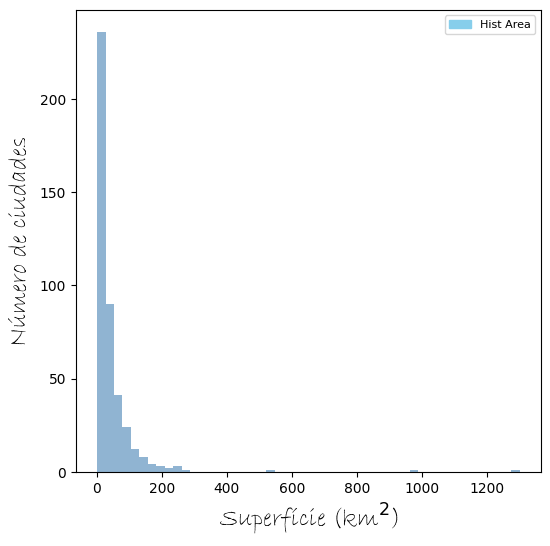

In [10]:
fig, ax = plt.subplots(figsize=(6, 6))
graph2(ax)

In [11]:
# 3. El scatter de área de agua de un ciudad con su poblacion.
def graph3(ax):
    pop = df_cities["population_total"].astype(float) / 1000
    area = df_cities["area_water_km2"]

    font8 = {'size': 8}

    ax.scatter(area, pop, color="green", s=50, alpha=0.7)
    ax.set_xlabel("Area de agua en la ciudad (km$^2$)", fontdict=font8)
    ax.set_ylabel("Población  (miles habitantes)", fontdict=font8)
    ax.set_title("Población por kilómetro cuadrado de agua", fontdict=font8)

    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

    flecha = {
        "arrowstyle": "->"
    }

    outliers = area[area > 80]
    out_x = outliers.values
    out_y = pop.loc[outliers.index].values

    ax.annotate("Outliers", xy = (out_x[0], out_y[0]), xytext = (60, 3500), arrowprops=flecha, fontsize=8) 
    ax.annotate("Outliers", xy = (out_x[1], out_y[1]), xytext = (60, 3500), arrowprops=flecha, fontsize=8); 


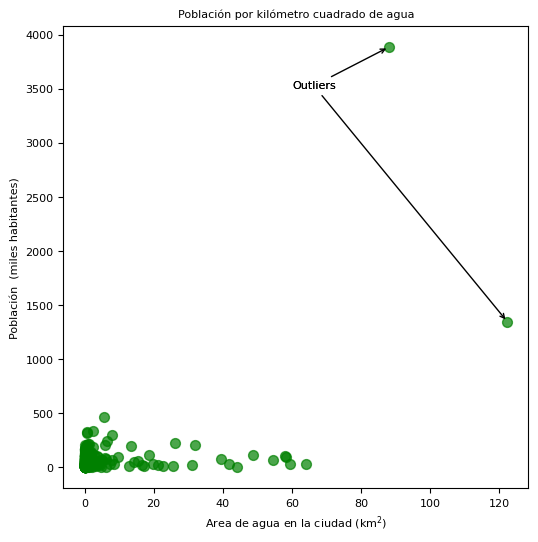

In [12]:
fig, ax = plt.subplots(figsize=(6, 6))
graph3(ax)

In [13]:
# 4. El boxplot de la altura de las ciudades.
def graph4(ax):

    font8 = {'size': 8}
    
    alt = df_cities["elevation_m"]
    ax.boxplot(alt, whis = 1.5, vert = False, patch_artist=True, boxprops=dict(facecolor="red"), medianprops=dict(color="black"));
    ax.set_xlabel("Altitud (m)", fontdict=font8)
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.set_title("Diagrama de caja de la Altitud de las ciudades de California", fontdict=font8);


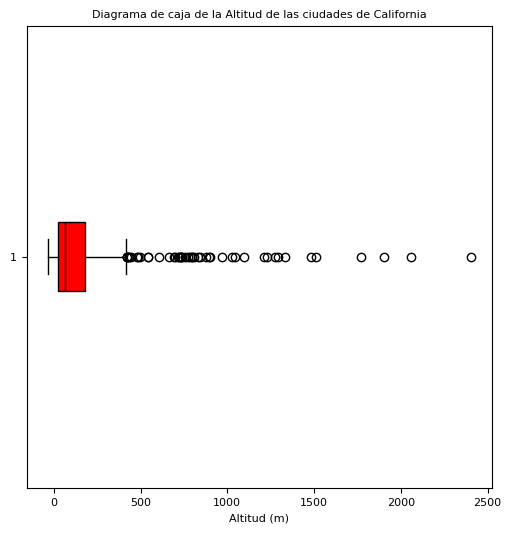

In [14]:
fig, ax = plt.subplots(figsize=(6, 6))
graph4(ax)

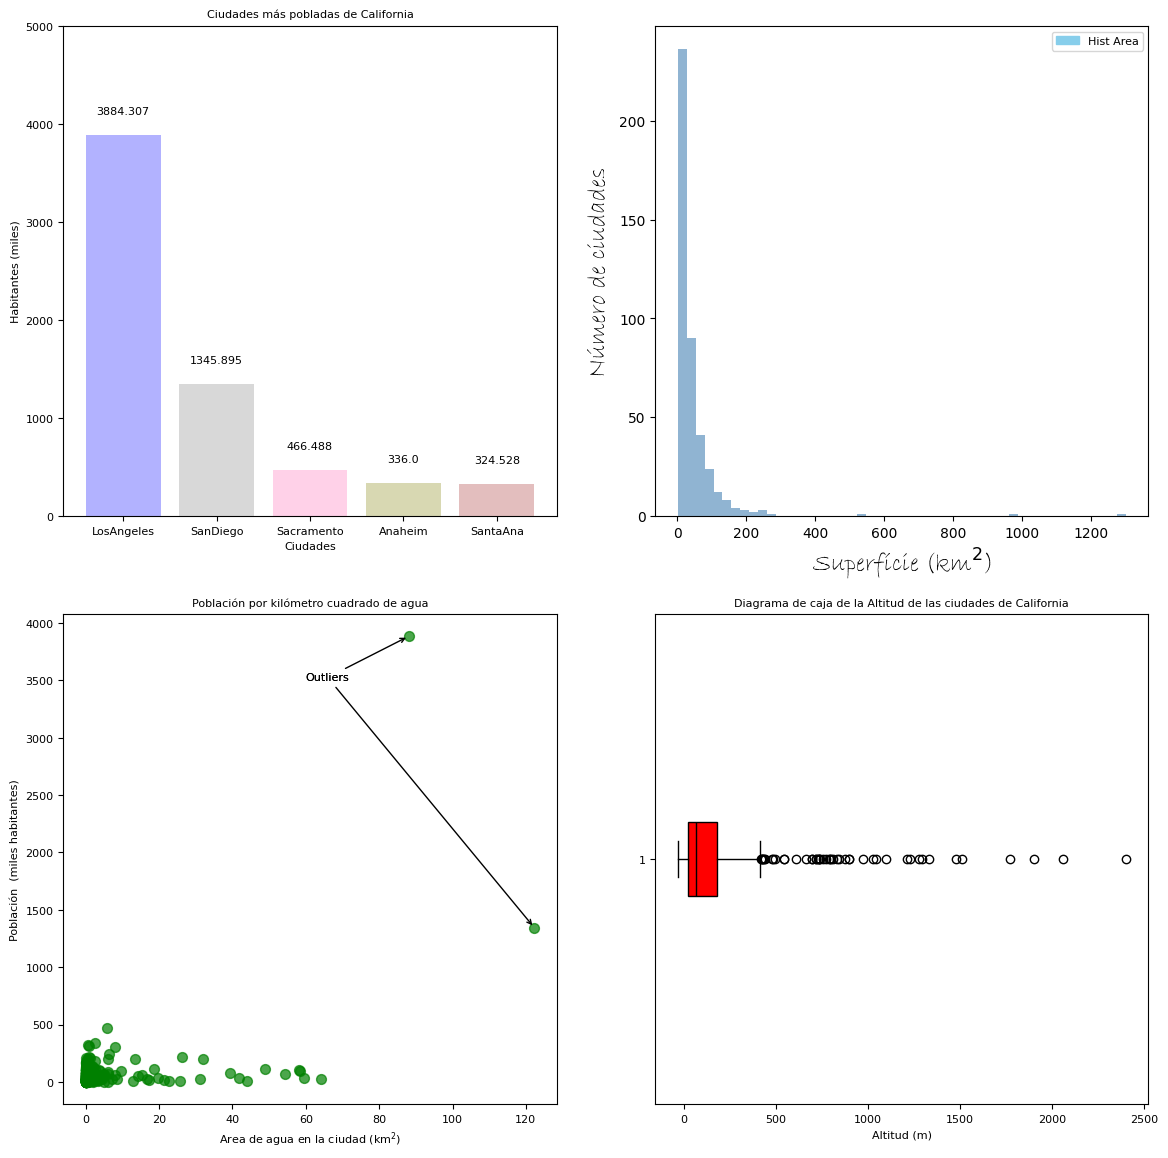

In [15]:
fig, ax = plt.subplots(2, 2, figsize=(14, 14))
graph1(ax[0, 0])
graph2(ax[0, 1])
graph3(ax[1, 0])
graph4(ax[1, 1])

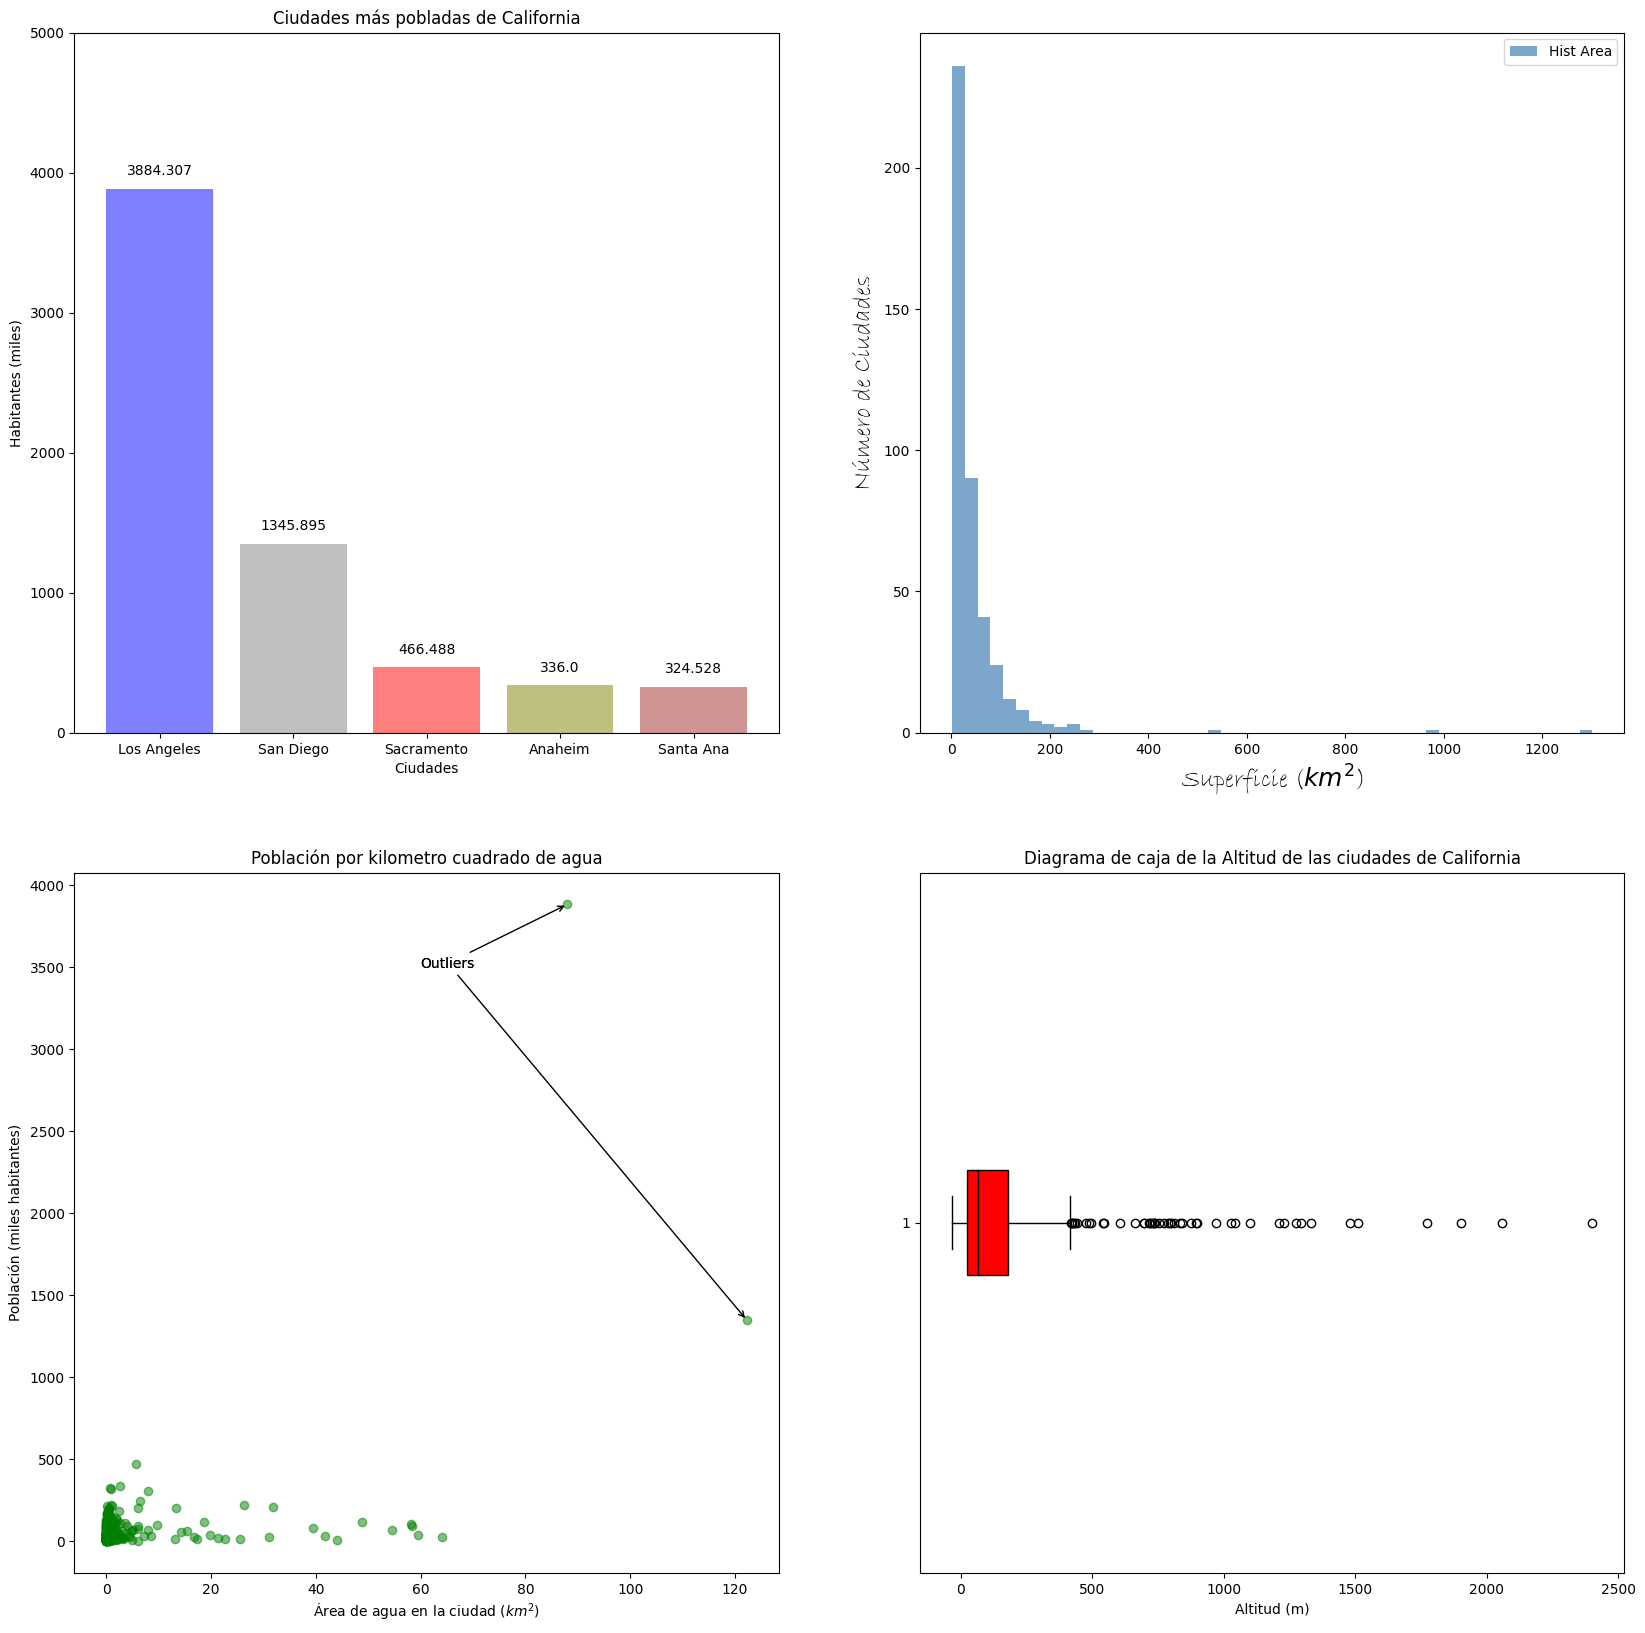

#### #1.3

Graba la figura en un archivo .png y sube el archivo a tu repositorio personal junto con el notebook.

In [16]:
fig.savefig("./img/MiPractica08_01.png")

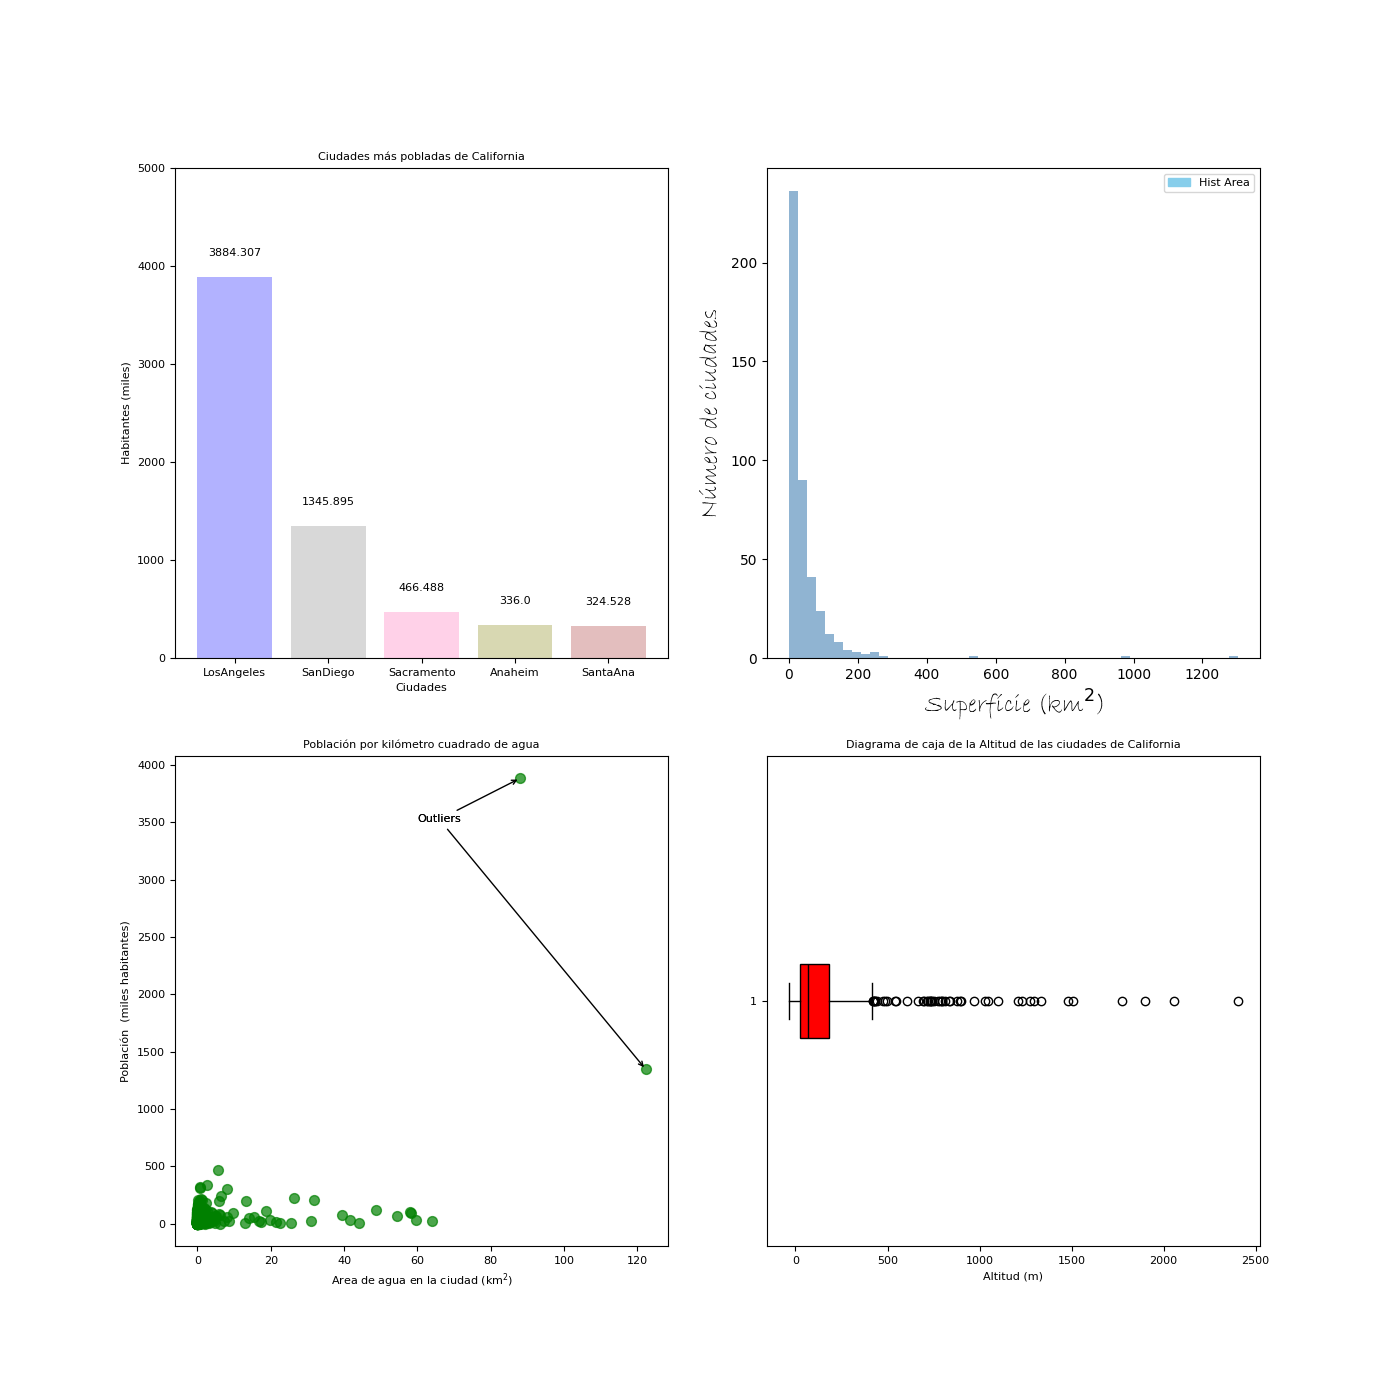

In [17]:
from IPython.display import Image
Image("./img/MiPractica08_01.png")